# Training Session 2 — Notes & Summary

**Objective:** Multi-stage classification of recyclable materials using a fine-tuned MobileNet-based CNN pipeline.  
**Stages:** Stage 1 (binary recyclable/non-recyclable), Stage 2 (material sub-categories), Stage 3 (Glass, Metal, Paper, Residual sub-class).  
**Key improvement over Session 1:** All stages include a fine-tuning phase with reduced learning rate.

## Executive Summary

| Stage | Best Val Accuracy | Test Accuracy | Test Loss | Test Precision | Test Recall |
|-------|-------------------|---------------|-----------|----------------|-------------|
| Stage 1 (binary) | **92.00%** (Ep 15) | 92.00% | 0.2041 | 98.84% | 85.00% |
| Stage 2 (5-class) | **92.00%** (Ep 16) | 90.00% | 0.2999 | 90.41% | 88.60% |
| Stage 3 Glass | **98.67%** (Ep 8) | 98.67% | 0.0413 | 98.67% | 98.67% |
| Stage 3 Metal | **96.00%** (Ep 14) | 96.67% | 0.0952 | 96.64% | 96.00% |
| Stage 3 Paper | **90.80%** (Ep 24) | 86.40% | 0.3447 | 87.60% | 84.80% |
| Stage 3 Residual | **97.50%** (Ep 21) | 96.50% | 0.0913 | 96.50% | 96.50% |
| Stage 3 Plastic | — | — | — | — | — |

**Highlight:** Stage 3 Glass achieved the best overall performance (98.67% test accuracy).  
Stage 3 Paper remains the most challenging sub-classification task (86.40% test accuracy).

## Stage 1 Training

### Stage 1 Summary

**Task:** Binary classification — *recyclable* vs *non-recyclable*  
**Dataset:** 200 test samples (100 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 66.31% | 93.00% | — |
| Val Accuracy | 79.00% | 92.00% | **92.00% (Ep 15)** |
| Train Loss | 0.6622 | 0.1649 | — |
| Val Loss | 0.4734 | 0.1899 | **0.1906 (Ep 1 FT)** |

**Fine-Tuning (10 epochs):** Starting val accuracy 92.00%; best val **92.00%** (Ep 1), final val 91.50%.

**Key Insights:**
- Model converged steadily from 66% to 93% training accuracy across 25 epochs.
- Fine-tuning maintained validation accuracy at 92.00%; test accuracy matched at **92.00%**.
- Near-perfect precision (98.84%) on the recyclable class; recall (85.00%) leaves room for improvement.
- Classification report shows slight asymmetry: non-recyclable recall 99% vs recyclable recall 85%.

### 1.1 Raw Training Logs

In [ ]:
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 954ms/step - accuracy: 0.6631 - loss: 0.6622 - precision_1: 0.6667 - recall_1: 0.6525 - val_accuracy: 0.7900 - val_loss: 0.4734 - val_precision_1: 0.7685 - val_recall_1: 0.8300 - learning_rate: 0.0010
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 828ms/step - accuracy: 0.7919 - loss: 0.4274 - precision_1: 0.7937 - recall_1: 0.7887 - val_accuracy: 0.8550 - val_loss: 0.3865 - val_precision_1: 0.8318 - val_recall_1: 0.8900 - learning_rate: 0.0010
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 784ms/step - accuracy: 0.8400 - loss: 0.3633 - precision_1: 0.8192 - recall_1: 0.8725 - val_accuracy: 0.8750 - val_loss: 0.3356 - val_precision_1: 0.8641 - val_recall_1: 0.8900 - learning_rate: 0.0010
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 683ms/step - accuracy: 0.8562 - loss: 0.3271 - precision_1: 0.8484 - recall_1: 0.8675 - val_accuracy: 0.8750 - val_loss: 0.3085 - val_precision_1: 0.8505 - val_recall_1: 0.9100 - learning_rate: 0.0010
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 663ms/step - accuracy: 0.8819 - loss: 0.2849 - precision_1: 0.8795 - recall_1: 0.8850 - val_accuracy: 0.8850 - val_loss: 0.2863 - val_precision_1: 0.8532 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 686ms/step - accuracy: 0.8963 - loss: 0.2638 - precision_1: 0.8894 - recall_1: 0.9050 - val_accuracy: 0.8750 - val_loss: 0.2772 - val_precision_1: 0.8319 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 648ms/step - accuracy: 0.9094 - loss: 0.2365 - precision_1: 0.9058 - recall_1: 0.9137 - val_accuracy: 0.9000 - val_loss: 0.2538 - val_precision_1: 0.8704 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 630ms/step - accuracy: 0.9112 - loss: 0.2300 - precision_1: 0.9042 - recall_1: 0.9200 - val_accuracy: 0.8750 - val_loss: 0.2552 - val_precision_1: 0.8319 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 656ms/step - accuracy: 0.9169 - loss: 0.2245 - precision_1: 0.9143 - recall_1: 0.9200 - val_accuracy: 0.8950 - val_loss: 0.2415 - val_precision_1: 0.8624 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 700ms/step - accuracy: 0.9231 - loss: 0.2090 - precision_1: 0.9103 - recall_1: 0.9388 - val_accuracy: 0.9000 - val_loss: 0.2341 - val_precision_1: 0.8704 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 655ms/step - accuracy: 0.9256 - loss: 0.2024 - precision_1: 0.9178 - recall_1: 0.9350 - val_accuracy: 0.8950 - val_loss: 0.2362 - val_precision_1: 0.8624 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 676ms/step - accuracy: 0.9162 - loss: 0.2157 - precision_1: 0.9091 - recall_1: 0.9250 - val_accuracy: 0.9000 - val_loss: 0.2281 - val_precision_1: 0.8704 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 13/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 715ms/step - accuracy: 0.9175 - loss: 0.2069 - precision_1: 0.9154 - recall_1: 0.9200 - val_accuracy: 0.9100 - val_loss: 0.2147 - val_precision_1: 0.8868 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 14/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 644ms/step - accuracy: 0.9275 - loss: 0.1901 - precision_1: 0.9233 - recall_1: 0.9325 - val_accuracy: 0.9050 - val_loss: 0.2193 - val_precision_1: 0.8785 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 15/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 653ms/step - accuracy: 0.9256 - loss: 0.1888 - precision_1: 0.9158 - recall_1: 0.9375 - val_accuracy: 0.9200 - val_loss: 0.2093 - val_precision_1: 0.9118 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 16/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 696ms/step - accuracy: 0.9281 - loss: 0.1851 - precision_1: 0.9234 - recall_1: 0.9337 - val_accuracy: 0.9150 - val_loss: 0.2082 - val_precision_1: 0.8952 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 17/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 666ms/step - accuracy: 0.9381 - loss: 0.1659 - precision_1: 0.9269 - recall_1: 0.9513 - val_accuracy: 0.8850 - val_loss: 0.2228 - val_precision_1: 0.8468 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 18/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 652ms/step - accuracy: 0.9269 - loss: 0.1675 - precision_1: 0.9190 - recall_1: 0.9362 - val_accuracy: 0.9050 - val_loss: 0.2057 - val_precision_1: 0.8857 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 19/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 661ms/step - accuracy: 0.9350 - loss: 0.1656 - precision_1: 0.9328 - recall_1: 0.9375 - val_accuracy: 0.9050 - val_loss: 0.2040 - val_precision_1: 0.8857 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 20/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 729ms/step - accuracy: 0.9375 - loss: 0.1613 - precision_1: 0.9364 - recall_1: 0.9388 - val_accuracy: 0.8850 - val_loss: 0.2141 - val_precision_1: 0.8468 - val_recall_1: 0.9400 - learning_rate: 0.0010
Epoch 21/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 716ms/step - accuracy: 0.9413 - loss: 0.1629 - precision_1: 0.9315 - recall_1: 0.9525 - val_accuracy: 0.9100 - val_loss: 0.2019 - val_precision_1: 0.8942 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 720ms/step - accuracy: 0.9381 - loss: 0.1621 - precision_1: 0.9354 - recall_1: 0.9413 - val_accuracy: 0.9050 - val_loss: 0.2010 - val_precision_1: 0.8857 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 834ms/step - accuracy: 0.9275 - loss: 0.1718 - precision_1: 0.9275 - recall_1: 0.9275 - val_accuracy: 0.9000 - val_loss: 0.2001 - val_precision_1: 0.8774 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 619ms/step - accuracy: 0.9406 - loss: 0.1545 - precision_1: 0.9368 - recall_1: 0.9450 - val_accuracy: 0.9000 - val_loss: 0.1955 - val_precision_1: 0.8774 - val_recall_1: 0.9300 - learning_rate: 0.0010
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 646ms/step - accuracy: 0.9300 - loss: 0.1649 - precision_1: 0.9205 - recall_1: 0.9413 - val_accuracy: 0.9200 - val_loss: 0.1899 - val_precision_1: 0.9200 - val_recall_1: 0.9200 - learning_rate: 0.0010

### 1.2 Fine-Tuning Logs

In [ ]:
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 937ms/step - accuracy: 0.9187 - loss: 0.2070 - precision_2: 0.9209 - recall_2: 0.9162 - val_accuracy: 0.9200 - val_loss: 0.1906 - val_precision_2: 0.9118 - val_recall_2: 0.9300
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 715ms/step - accuracy: 0.9244 - loss: 0.2000 - precision_2: 0.9249 - recall_2: 0.9237 - val_accuracy: 0.9200 - val_loss: 0.1921 - val_precision_2: 0.9118 - val_recall_2: 0.9300
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 741ms/step - accuracy: 0.9206 - loss: 0.1958 - precision_2: 0.9276 - recall_2: 0.9125 - val_accuracy: 0.9150 - val_loss: 0.1933 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 734ms/step - accuracy: 0.9312 - loss: 0.1768 - precision_2: 0.9323 - recall_2: 0.9300 - val_accuracy: 0.9150 - val_loss: 0.1936 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 738ms/step - accuracy: 0.9325 - loss: 0.1868 - precision_2: 0.9240 - recall_2: 0.9425 - val_accuracy: 0.9150 - val_loss: 0.1936 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 745ms/step - accuracy: 0.9381 - loss: 0.1719 - precision_2: 0.9333 - recall_2: 0.9438 - val_accuracy: 0.9150 - val_loss: 0.1933 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 727ms/step - accuracy: 0.9362 - loss: 0.1754 - precision_2: 0.9362 - recall_2: 0.9362 - val_accuracy: 0.9150 - val_loss: 0.1936 - val_precision_2: 0.9029 - val_recall_2: 0.9300
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9450 - loss: 0.1507 - precision_2: 0.9373 - recall_2: 0.9538 - val_accuracy: 0.9100 - val_loss: 0.1943 - val_precision_2: 0.8942 - val_recall_2: 0.9300
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 942ms/step - accuracy: 0.9350 - loss: 0.1711 - precision_2: 0.9234 - recall_2: 0.9488 - val_accuracy: 0.9100 - val_loss: 0.1938 - val_precision_2: 0.8942 - val_recall_2: 0.9300
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 812ms/step - accuracy: 0.9513 - loss: 0.1399 - precision_2: 0.9468 - recall_2: 0.9563 - val_accuracy: 0.9150 - val_loss: 0.1931 - val_precision_2: 0.9029 - val_recall_2: 0.9300

### 1.3 Training Curves

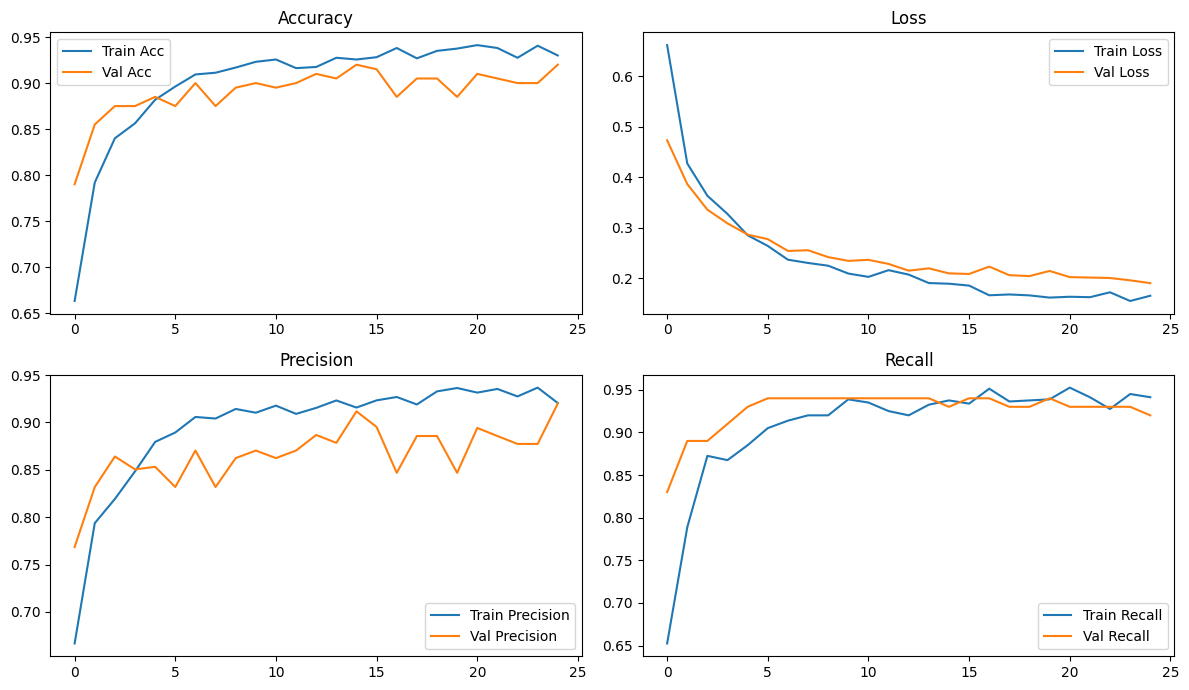

### 1.4 Test Results

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9200 - loss: 0.2041 - precision_2: 0.9884 - recall_2: 0.8500   
Test Loss: 0.2041
Test Acc:  0.9200
Test Prec: 0.9884
Test Rec:  0.8500

                precision    recall  f1-score   support

    non-recyclable   0.87      0.99      0.93       100
      recyclable     0.99      0.85      0.91       100

      accuracy                           0.92       200
     macro avg       0.93      0.92      0.92       200
  weighted avg       0.93      0.92      0.92       200

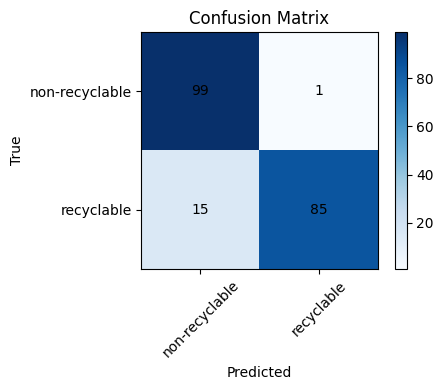

## Stage 2 Training

### Stage 2 Summary

**Task:** Multi-class classification — 5 recyclable material categories  
**Classes:** glass, metal, paper, plastic, residual  
**Dataset:** 500 test samples (100 per class)

| Metric | Epoch 1 | Final (Ep 20) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 49.02% | 94.70% | — |
| Val Accuracy | 75.40% | 91.60% | **92.00% (Ep 16)** |
| Train Loss | 1.4101 | 0.1587 | — |
| Val Loss | 0.7108 | 0.2412 | **0.2591 (Ep 16)** |

**Fine-Tuning (stopped at Ep 5/10):** Starting val accuracy 91.80%; best val **91.80%** (Ep 1), final val 91.20%.

**Key Insights:**
- Strong improvement from 49% to 94.70% training accuracy over 20 epochs.
- Fine-tuning plateaued early; early stopping triggered around Ep 5.
- Test accuracy 90.00% across all 5 classes; residual class led with 98% precision.
- Paper and glass sub-categories were most challenging (85–90% per-class F1).

### 2.1 Raw Training Logs

In [ ]:
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.4902 - loss: 1.4101 - precision: 0.5668 - recall: 0.3753 - val_accuracy: 0.7540 - val_loss: 0.7108 - val_precision: 0.8311 - val_recall: 0.6300 - learning_rate: 1.0000e-04
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7097 - loss: 0.7885 - precision: 0.7838 - recall: 0.6352 - val_accuracy: 0.8120 - val_loss: 0.5296 - val_precision: 0.8647 - val_recall: 0.7540 - learning_rate: 1.0000e-04
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7940 - loss: 0.5950 - precision: 0.8442 - recall: 0.7315 - val_accuracy: 0.8560 - val_loss: 0.4375 - val_precision: 0.8818 - val_recall: 0.8060 - learning_rate: 1.0000e-04
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8192 - loss: 0.5180 - precision: 0.8645 - recall: 0.7722 - val_accuracy: 0.8720 - val_loss: 0.3966 - val_precision: 0.8928 - val_recall: 0.8160 - learning_rate: 1.0000e-04
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8553 - loss: 0.4354 - precision: 0.8875 - recall: 0.8148 - val_accuracy: 0.8800 - val_loss: 0.3710 - val_precision: 0.8974 - val_recall: 0.8400 - learning_rate: 1.0000e-04
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8608 - loss: 0.3913 - precision: 0.8957 - recall: 0.8265 - val_accuracy: 0.8960 - val_loss: 0.3428 - val_precision: 0.9151 - val_recall: 0.8620 - learning_rate: 1.0000e-04
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.8765 - loss: 0.3575 - precision: 0.9051 - recall: 0.8465 - val_accuracy: 0.9000 - val_loss: 0.3247 - val_precision: 0.9116 - val_recall: 0.8660 - learning_rate: 1.0000e-04
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8850 - loss: 0.3287 - precision: 0.9122 - recall: 0.8543 - val_accuracy: 0.8960 - val_loss: 0.3101 - val_precision: 0.9160 - val_recall: 0.8720 - learning_rate: 1.0000e-04
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8917 - loss: 0.3116 - precision: 0.9150 - recall: 0.8665 - val_accuracy: 0.9020 - val_loss: 0.3027 - val_precision: 0.9146 - val_recall: 0.8780 - learning_rate: 1.0000e-04
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9018 - loss: 0.2906 - precision: 0.9253 - recall: 0.8827 - val_accuracy: 0.9060 - val_loss: 0.2970 - val_precision: 0.9210 - val_recall: 0.8860 - learning_rate: 1.0000e-04
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9140 - loss: 0.2583 - precision: 0.9359 - recall: 0.8903 - val_accuracy: 0.9060 - val_loss: 0.2883 - val_precision: 0.9236 - val_recall: 0.8940 - learning_rate: 1.0000e-04
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9185 - loss: 0.2474 - precision: 0.9345 - recall: 0.8953 - val_accuracy: 0.9100 - val_loss: 0.2797 - val_precision: 0.9275 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 13/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9212 - loss: 0.2258 - precision: 0.9420 - recall: 0.8972 - val_accuracy: 0.9060 - val_loss: 0.2760 - val_precision: 0.9255 - val_recall: 0.8940 - learning_rate: 1.0000e-04
Epoch 14/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9330 - loss: 0.2118 - precision: 0.9509 - recall: 0.9143 - val_accuracy: 0.9120 - val_loss: 0.2693 - val_precision: 0.9312 - val_recall: 0.8940 - learning_rate: 1.0000e-04
Epoch 15/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9360 - loss: 0.2014 - precision: 0.9489 - recall: 0.9230 - val_accuracy: 0.9160 - val_loss: 0.2694 - val_precision: 0.9299 - val_recall: 0.9020 - learning_rate: 1.0000e-04
Epoch 16/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9300 - loss: 0.1955 - precision: 0.9465 - recall: 0.9147 - val_accuracy: 0.9200 - val_loss: 0.2591 - val_precision: 0.9296 - val_recall: 0.8980 - learning_rate: 1.0000e-04
Epoch 17/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9333 - loss: 0.1934 - precision: 0.9488 - recall: 0.9175 - val_accuracy: 0.9200 - val_loss: 0.2551 - val_precision: 0.9342 - val_recall: 0.9080 - learning_rate: 1.0000e-04
Epoch 18/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9375 - loss: 0.1824 - precision: 0.9491 - recall: 0.9227 - val_accuracy: 0.9180 - val_loss: 0.2558 - val_precision: 0.9322 - val_recall: 0.9080 - learning_rate: 1.0000e-04
Epoch 19/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.9477 - loss: 0.1672 - precision: 0.9578 - recall: 0.9365 - val_accuracy: 0.9180 - val_loss: 0.2504 - val_precision: 0.9324 - val_recall: 0.9100 - learning_rate: 1.0000e-04
Epoch 20/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.9470 - loss: 0.1587 - precision: 0.9599 - recall: 0.9337 - val_accuracy: 0.9160 - val_loss: 0.2412 - val_precision: 0.9325 - val_recall: 0.9120 - learning_rate: 1.0000e-04

### 2.2 Fine-Tuning Logs

In [ ]:
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8960 - loss: 0.2980 - precision: 0.9178 - recall: 0.8733 - val_accuracy: 0.9180 - val_loss: 0.2609 - val_precision: 0.9305 - val_recall: 0.9100 - learning_rate: 1.0000e-05
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9136 - loss: 0.2586 - precision: 0.9334 - recall: 0.8845
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
125/125 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9150 - loss: 0.2546 - precision: 0.9309 - recall: 0.8923 - val_accuracy: 0.9160 - val_loss: 0.2710 - val_precision: 0.9245 - val_recall: 0.9060 - learning_rate: 1.0000e-05
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9230 - loss: 0.2330 - precision: 0.9402 - recall: 0.9035 - val_accuracy: 0.9120 - val_loss: 0.2696 - val_precision: 0.9206 - val_recall: 0.9040 - learning_rate: 5.0000e-06
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9177 - loss: 0.2413 - precision: 0.9422 - recall: 0.8976
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
125/125 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9158 - loss: 0.2403 - precision: 0.9397 - recall: 0.8992 - val_accuracy: 0.9100 - val_loss: 0.2683 - val_precision: 0.9226 - val_recall: 0.9060 - learning_rate: 5.0000e-06
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9277 - loss: 0.2221 - precision: 0.9461 - recall: 0.9082 - val_accuracy: 0.9120 - val_loss: 0.2669 - val_precision: 0.9226 - val_recall: 0.9060 - learning_rate: 2.5000e-06

### 2.3 Training Curves

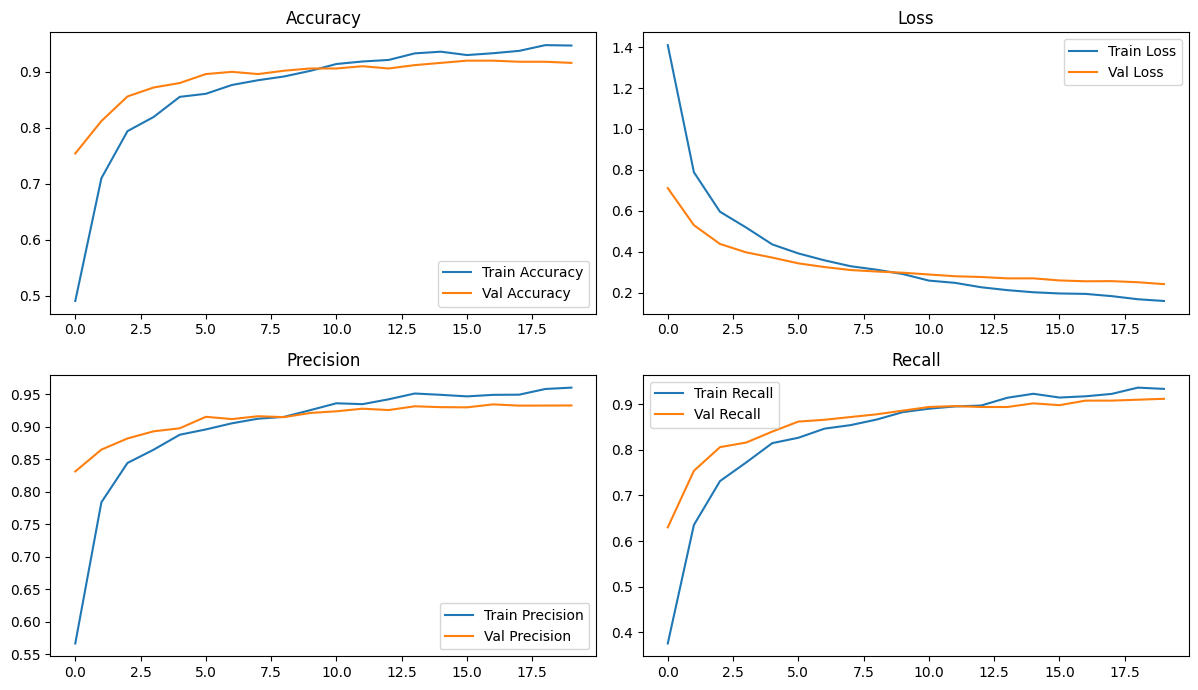

### 2.4 Test Results

16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 950ms/step - accuracy: 0.9000 - loss: 0.2999 - precision: 0.9041 - recall: 0.8860

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 806ms/step

              precision    recall  f1-score   support

       glass       0.90      0.89      0.89       100
       metal       0.89      0.82      0.85       100
       paper       0.85      0.95      0.90       100
     plastic       0.90      0.95      0.92       100
    residual       0.98      0.89      0.93       100

    accuracy                           0.90       500
    macro avg       0.90      0.90      0.90       500
    weighted avg       0.90      0.90      0.90       500


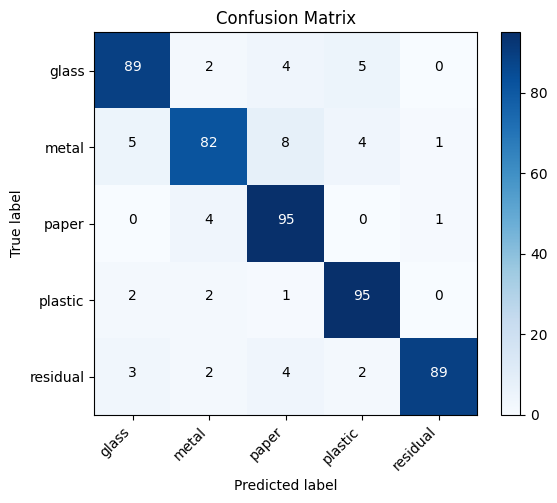

## Stage 3: Glass

### Stage 3 Glass Summary

**Task:** Multi-class classification of glass sub-types (3 classes)  
**Classes:** glass_bottles, glass_cullets, glass_flat_glass  
**Dataset:** 150 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 23) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 65.58% | 98.50% | — |
| Val Accuracy | 90.67% | 98.00% | **98.67% (Ep 8)** |
| Train Loss | 0.8320 | 0.0490 | — |
| Val Loss | 0.2566 | 0.0510 | **0.0588 (Ep 8)** |

**Fine-Tuning (stopped at Ep 5/10):** Starting val accuracy 97.33%; best val **97.33%** (Ep 1), final val 96.00%.

**Key Insights:**
- Fastest Stage 3 convergence; already 90.67% val accuracy after Epoch 1.
- Best validation performance across all stages: **98.67%** at Ep 8.
- Test accuracy 98.67% — near-perfect across all three glass sub-types.
- glass_flat_glass achieved perfect precision (1.00); glass_cullets showed consistent 98% F1.

### 3a.1 Raw Training Logs

In [ ]:
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6558 - loss: 0.8320 - precision: 0.6828 - recall: 0.6100 - val_accuracy: 0.9067 - val_loss: 0.2566 - val_precision: 0.9122 - val_recall: 0.9000 - learning_rate: 1.0000e-04
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9017 - loss: 0.2931 - precision: 0.9160 - recall: 0.8900 - val_accuracy: 0.9333 - val_loss: 0.1748 - val_precision: 0.9396 - val_recall: 0.9333 - learning_rate: 1.0000e-04
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9275 - loss: 0.2137 - precision: 0.9345 - recall: 0.9158 - val_accuracy: 0.9667 - val_loss: 0.1117 - val_precision: 0.9667 - val_recall: 0.9667 - learning_rate: 1.0000e-04
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9408 - loss: 0.1591 - precision: 0.9470 - recall: 0.9375 - val_accuracy: 0.9667 - val_loss: 0.1207 - val_precision: 0.9667 - val_recall: 0.9667 - learning_rate: 1.0000e-04
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 984ms/step - accuracy: 0.9475 - loss: 0.1361 - precision: 0.9554 - recall: 0.9458 - val_accuracy: 0.9667 - val_loss: 0.0938 - val_precision: 0.9667 - val_recall: 0.9667 - learning_rate: 1.0000e-04
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9592 - loss: 0.1268 - precision: 0.9647 - recall: 0.9575 - val_accuracy: 0.9733 - val_loss: 0.0773 - val_precision: 0.9733 - val_recall: 0.9733 - learning_rate: 1.0000e-04
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 913ms/step - accuracy: 0.9642 - loss: 0.0951 - precision: 0.9681 - recall: 0.9617 - val_accuracy: 0.9667 - val_loss: 0.0773 - val_precision: 0.9667 - val_recall: 0.9667 - learning_rate: 1.0000e-04
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 879ms/step - accuracy: 0.9692 - loss: 0.0825 - precision: 0.9707 - recall: 0.9675 - val_accuracy: 0.9867 - val_loss: 0.0588 - val_precision: 0.9867 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 860ms/step - accuracy: 0.9750 - loss: 0.0769 - precision: 0.9774 - recall: 0.9725 - val_accuracy: 0.9800 - val_loss: 0.0619 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 1.0000e-04
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9693 - loss: 0.0739 - precision: 0.9738 - recall: 0.9654
Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 848ms/step - accuracy: 0.9708 - loss: 0.0789 - precision: 0.9724 - recall: 0.9683 - val_accuracy: 0.9800 - val_loss: 0.0632 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 1.0000e-04
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 853ms/step - accuracy: 0.9817 - loss: 0.0563 - precision: 0.9833 - recall: 0.9808 - val_accuracy: 0.9800 - val_loss: 0.0608 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 854ms/step - accuracy: 0.9775 - loss: 0.0574 - precision: 0.9783 - recall: 0.9750 - val_accuracy: 0.9867 - val_loss: 0.0535 - val_precision: 0.9867 - val_recall: 0.9867 - learning_rate: 5.0000e-05
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 849ms/step - accuracy: 0.9800 - loss: 0.0642 - precision: 0.9808 - recall: 0.9792 - val_accuracy: 0.9800 - val_loss: 0.0564 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.9915 - loss: 0.0408 - precision: 0.9914 - recall: 0.9877
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 841ms/step - accuracy: 0.9858 - loss: 0.0514 - precision: 0.9858 - recall: 0.9817 - val_accuracy: 0.9800 - val_loss: 0.0543 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 852ms/step - accuracy: 0.9833 - loss: 0.0475 - precision: 0.9850 - recall: 0.9825 - val_accuracy: 0.9800 - val_loss: 0.0543 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 16/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 852ms/step - accuracy: 0.9883 - loss: 0.0504 - precision: 0.9891 - recall: 0.9867 - val_accuracy: 0.9800 - val_loss: 0.0529 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 17/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 888ms/step - accuracy: 0.9875 - loss: 0.0458 - precision: 0.9883 - recall: 0.9875 - val_accuracy: 0.9800 - val_loss: 0.0527 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 18/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 858ms/step - accuracy: 0.9875 - loss: 0.0457 - precision: 0.9891 - recall: 0.9858 - val_accuracy: 0.9800 - val_loss: 0.0499 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 19/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 874ms/step - accuracy: 0.9833 - loss: 0.0467 - precision: 0.9833 - recall: 0.9817 - val_accuracy: 0.9800 - val_loss: 0.0526 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 20/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.9833 - loss: 0.0452 - precision: 0.9855 - recall: 0.9815
Epoch 20: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 837ms/step - accuracy: 0.9808 - loss: 0.0518 - precision: 0.9833 - recall: 0.9792 - val_accuracy: 0.9800 - val_loss: 0.0526 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 21/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9842 - loss: 0.0521 - precision: 0.9858 - recall: 0.9842 - val_accuracy: 0.9800 - val_loss: 0.0521 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 1.2500e-05
Epoch 22/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.9891 - loss: 0.0454 - precision: 0.9916 - recall: 0.9864
Epoch 22: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9875 - loss: 0.0441 - precision: 0.9891 - recall: 0.9858 - val_accuracy: 0.9800 - val_loss: 0.0511 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 1.2500e-05
Epoch 23/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 944ms/step - accuracy: 0.9850 - loss: 0.0490 - precision: 0.9858 - recall: 0.9825 - val_accuracy: 0.9800 - val_loss: 0.0510 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 6.2500e-06

### 3a.2 Fine-Tuning Logs

In [ ]:
Fine tune

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9642 - loss: 0.1210 - precision: 0.9681 - recall: 0.9608 - val_accuracy: 0.9733 - val_loss: 0.0677 - val_precision: 0.9733 - val_recall: 0.9733 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9753 - loss: 0.0922 - precision: 0.9760 - recall: 0.9706
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9767 - loss: 0.0937 - precision: 0.9790 - recall: 0.9708 - val_accuracy: 0.9600 - val_loss: 0.0723 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 1.0000e-05
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9767 - loss: 0.0882 - precision: 0.9782 - recall: 0.9742 - val_accuracy: 0.9600 - val_loss: 0.0754 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 5.0000e-06
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.9676 - loss: 0.1099 - precision: 0.9750 - recall: 0.9627
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9717 - loss: 0.0989 - precision: 0.9781 - recall: 0.9667 - val_accuracy: 0.9600 - val_loss: 0.0740 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 5.0000e-06
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9675 - loss: 0.0934 - precision: 0.9739 - recall: 0.9650 - val_accuracy: 0.9600 - val_loss: 0.0734 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 2.5000e-06

### 3a.3 Training Curves

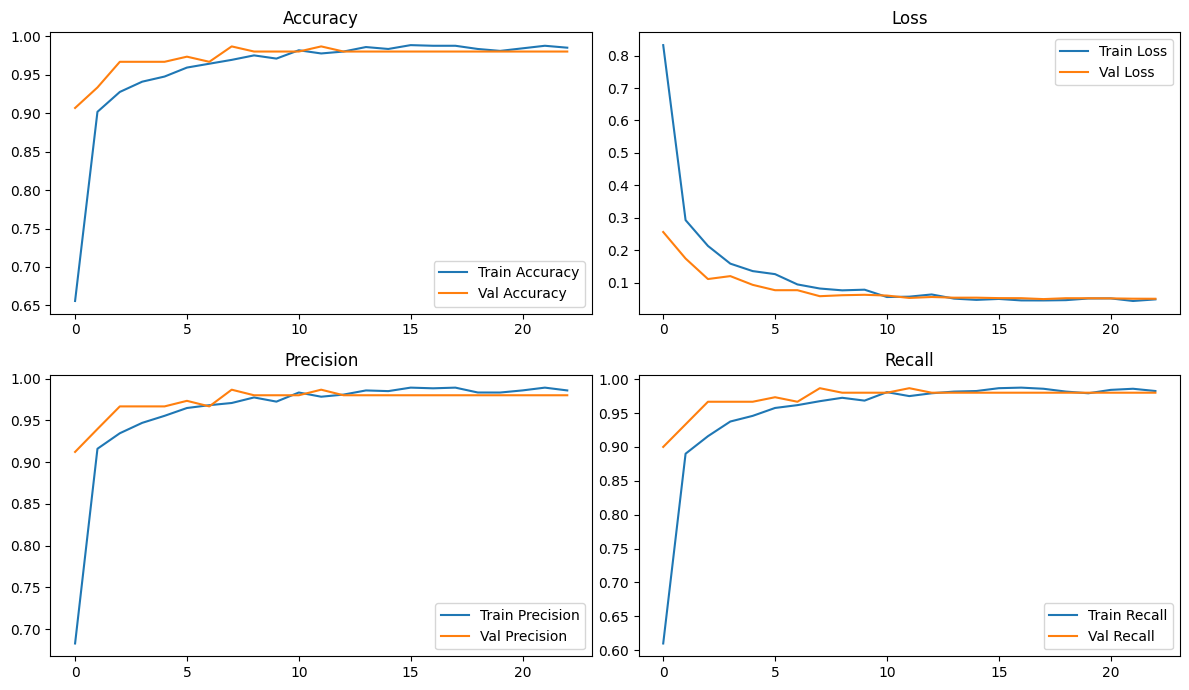

### 3a.4 Test Results

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.9867 - loss: 0.0413 - precision: 0.9867 - recall: 0.9867

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 592ms/step

                  precision    recall  f1-score   support

      glass_bottles    0.98      1.00      0.99        50
      glass_cullets    0.98      0.98      0.98        50
      glass_flat_glass 1.00      0.98      0.99        50

        accuracy                           0.99       150
       macro avg       0.99      0.99      0.99       150
    weighted avg       0.99      0.99      0.99       150

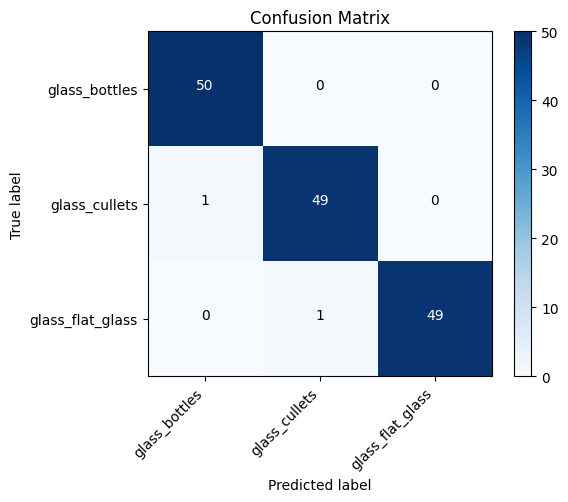

## Stage 3: Metal

### Stage 3 Metal Summary

**Task:** Multi-class classification of metal sub-types (3 classes)  
**Classes:** aluminum_tin, copper, steel  
**Dataset:** 150 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 22) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 46.83% | 96.67% | — |
| Val Accuracy | 78.67% | 95.33% | **96.00% (Ep 14)** |
| Train Loss | 1.3048 | 0.0916 | — |
| Val Loss | 0.5325 | 0.1067 | **0.1138 (Ep 14)** |

**Fine-Tuning (stopped at Ep 6/10):** Starting val accuracy 95.33%; best val **95.33%** (Ep 1), final val 95.33%.

**Key Insights:**
- Steady convergence from 46.83% to 96.67% training accuracy over 22 epochs.
- Fine-tuning stabilised validation accuracy; early stopping around Ep 6.
- Test accuracy 96.67%; copper class achieved perfect recall (1.00).
- Steel showed slightly lower recall at 92%, contributing to marginal F1 gap.

### 3b.1 Raw Training Logs

In [ ]:
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.4683 - loss: 1.3048 - precision: 0.4885 - recall: 0.4250 - val_accuracy: 0.7867 - val_loss: 0.5325 - val_precision: 0.8320 - val_recall: 0.6933 - learning_rate: 1.0000e-04
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7642 - loss: 0.5918 - precision: 0.7921 - recall: 0.7333 - val_accuracy: 0.8933 - val_loss: 0.3128 - val_precision: 0.9197 - val_recall: 0.8400 - learning_rate: 1.0000e-04
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 973ms/step - accuracy: 0.8175 - loss: 0.4351 - precision: 0.8417 - recall: 0.7933 - val_accuracy: 0.9267 - val_loss: 0.2253 - val_precision: 0.9444 - val_recall: 0.9067 - learning_rate: 1.0000e-04
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8850 - loss: 0.3082 - precision: 0.8922 - recall: 0.8692 - val_accuracy: 0.9467 - val_loss: 0.1883 - val_precision: 0.9524 - val_recall: 0.9333 - learning_rate: 1.0000e-04
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8958 - loss: 0.2755 - precision: 0.9017 - recall: 0.8867 - val_accuracy: 0.9467 - val_loss: 0.1673 - val_precision: 0.9527 - val_recall: 0.9400 - learning_rate: 1.0000e-04
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 964ms/step - accuracy: 0.9083 - loss: 0.2458 - precision: 0.9136 - recall: 0.8983 - val_accuracy: 0.9533 - val_loss: 0.1507 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 966ms/step - accuracy: 0.9267 - loss: 0.2142 - precision: 0.9296 - recall: 0.9242 - val_accuracy: 0.9533 - val_loss: 0.1395 - val_precision: 0.9533 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9292 - loss: 0.1801 - precision: 0.9365 - recall: 0.9217 - val_accuracy: 0.9533 - val_loss: 0.1319 - val_precision: 0.9533 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9408 - loss: 0.1622 - precision: 0.9422 - recall: 0.9367 - val_accuracy: 0.9533 - val_loss: 0.1292 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9367 - loss: 0.1506 - precision: 0.9428 - recall: 0.9342 - val_accuracy: 0.9533 - val_loss: 0.1236 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9517 - loss: 0.1357 - precision: 0.9547 - recall: 0.9475 - val_accuracy: 0.9533 - val_loss: 0.1223 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9525 - loss: 0.1386 - precision: 0.9540 - recall: 0.9500 - val_accuracy: 0.9533 - val_loss: 0.1159 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9558 - loss: 0.1233 - precision: 0.9582 - recall: 0.9542 - val_accuracy: 0.9533 - val_loss: 0.1167 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9575 - loss: 0.1115 - precision: 0.9614 - recall: 0.9550 - val_accuracy: 0.9600 - val_loss: 0.1138 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 973ms/step - accuracy: 0.9642 - loss: 0.1094 - precision: 0.9680 - recall: 0.9583 - val_accuracy: 0.9600 - val_loss: 0.1093 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 16/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 925ms/step - accuracy: 0.9633 - loss: 0.1081 - precision: 0.9649 - recall: 0.9625 - val_accuracy: 0.9600 - val_loss: 0.1086 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 17/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 937ms/step - accuracy: 0.9683 - loss: 0.0933 - precision: 0.9699 - recall: 0.9658 - val_accuracy: 0.9600 - val_loss: 0.1057 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 18/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 947ms/step - accuracy: 0.9742 - loss: 0.0814 - precision: 0.9741 - recall: 0.9733 - val_accuracy: 0.9533 - val_loss: 0.1061 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 19/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9694 - loss: 0.0769 - precision: 0.9693 - recall: 0.9668
Epoch 19: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 920ms/step - accuracy: 0.9725 - loss: 0.0800 - precision: 0.9724 - recall: 0.9683 - val_accuracy: 0.9600 - val_loss: 0.1071 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-04
Epoch 20/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 935ms/step - accuracy: 0.9733 - loss: 0.0799 - precision: 0.9741 - recall: 0.9717 - val_accuracy: 0.9533 - val_loss: 0.1062 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 5.0000e-05
Epoch 21/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9793 - loss: 0.0707 - precision: 0.9809 - recall: 0.9791
Epoch 21: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 920ms/step - accuracy: 0.9808 - loss: 0.0744 - precision: 0.9816 - recall: 0.9792 - val_accuracy: 0.9533 - val_loss: 0.1058 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 5.0000e-05
Epoch 22/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 918ms/step - accuracy: 0.9667 - loss: 0.0916 - precision: 0.9675 - recall: 0.9667 - val_accuracy: 0.9533 - val_loss: 0.1067 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 2.5000e-05

### 3b.2 Fine-Tuning Logs

In [ ]:
Fine tune

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9417 - loss: 0.1680 - precision: 0.9461 - recall: 0.9358 - val_accuracy: 0.9533 - val_loss: 0.1048 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9558 - loss: 0.1305 - precision: 0.9636 - recall: 0.9475 - val_accuracy: 0.9533 - val_loss: 0.1056 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-05
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9553 - loss: 0.1481 - precision: 0.9611 - recall: 0.9508
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9533 - loss: 0.1505 - precision: 0.9571 - recall: 0.9475 - val_accuracy: 0.9533 - val_loss: 0.1054 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 1.0000e-05
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9592 - loss: 0.1288 - precision: 0.9630 - recall: 0.9550 - val_accuracy: 0.9533 - val_loss: 0.1052 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 5.0000e-06
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9482 - loss: 0.1429 - precision: 0.9564 - recall: 0.9441
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9433 - loss: 0.1480 - precision: 0.9501 - recall: 0.9358 - val_accuracy: 0.9533 - val_loss: 0.1052 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 5.0000e-06
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9567 - loss: 0.1316 - precision: 0.9621 - recall: 0.9525 - val_accuracy: 0.9533 - val_loss: 0.1054 - val_precision: 0.9597 - val_recall: 0.9533 - learning_rate: 2.5000e-06

### 3b.3 Training Curves

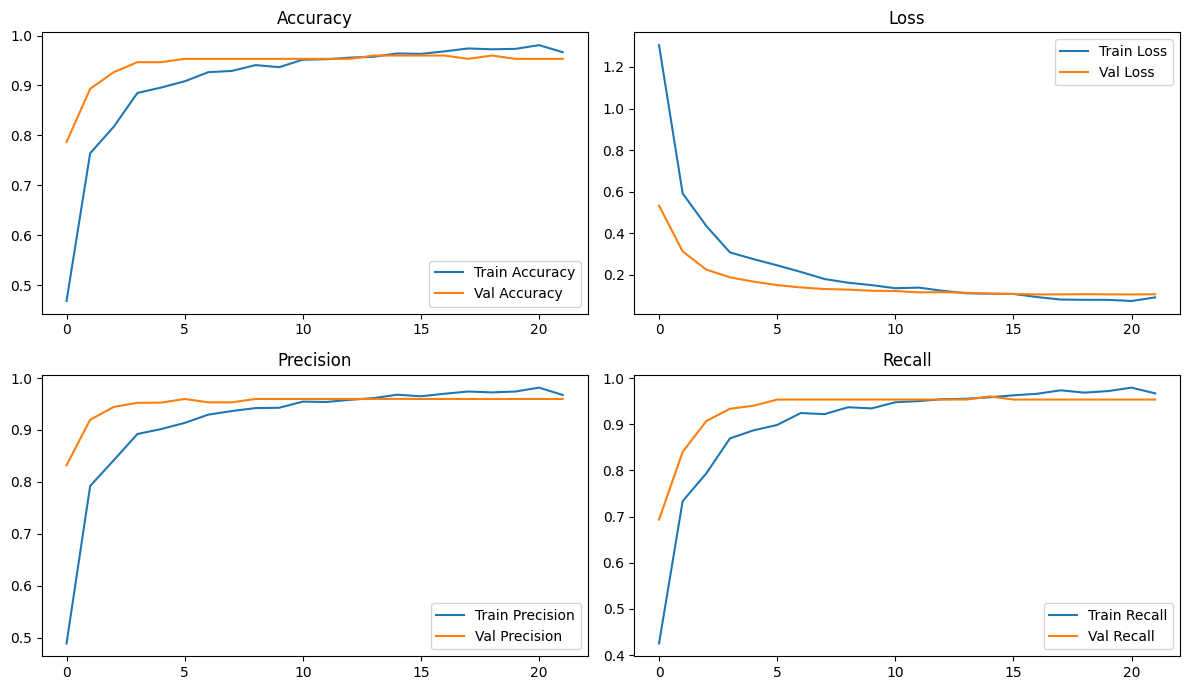

### 3b.4 Test Results

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 720ms/step - accuracy: 0.9667 - loss: 0.0952 - precision: 0.9664 - recall: 0.9600

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 934ms/step

              precision    recall  f1-score   support

    aluminum_tin   0.98      0.98      0.98        50
      copper       0.93      1.00      0.96        50
       steel       1.00      0.92      0.96        50

    accuracy                           0.97       150
    macro avg       0.97      0.97      0.97       150
    weighted avg       0.97      0.97      0.97       150


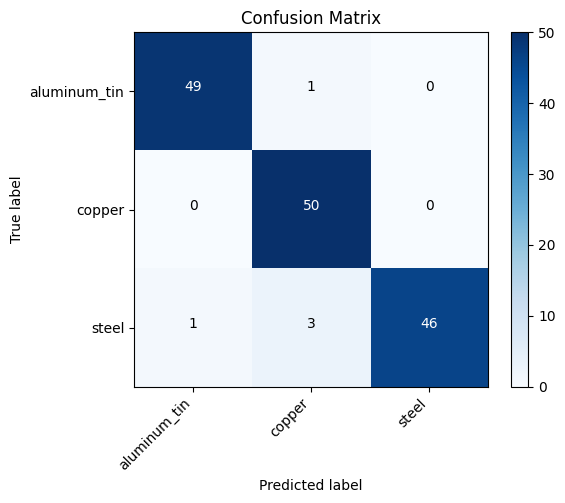

## Stage 3: Paper

### Stage 3 Paper Summary

**Task:** Multi-class classification of paper sub-types (5 classes)  
**Classes:** mixed_paper, old_corrugated_cartons, old_newspaper, selected_white_ledger, used_beverage_cartons  
**Dataset:** 250 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 41.10% | ~89.60% | — |
| Val Accuracy | 67.20% | 90.40% | **90.80% (Ep 24)** |
| Train Loss | 1.5542 | 0.2897 | — |
| Val Loss | 0.8626 | 0.2770 | **0.2621 (Ep 24)** |

**Fine-Tuning (stopped at Ep 6/10):** Starting val accuracy 90.80%; best val **90.80%** (Ep 1), final val 90.40%.

**Key Insights:**
- Most challenging Stage 3 task due to 5 visually similar paper sub-types.
- Slower convergence; val accuracy still improving near Ep 24.
- Test accuracy 86.40%; mixed_paper class most difficult (70% F1 — visual similarity with newspaper).
- used_beverage_cartons and old_corrugated_cartons achieved strong 94%+ F1 scores.

### 3c.1 Raw Training Logs

In [ ]:
Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.4110 - loss: 1.5542 - precision: 0.4936 - recall: 0.2875 - val_accuracy: 0.6720 - val_loss: 0.8626 - val_precision: 0.8243 - val_recall: 0.4880 - learning_rate: 1.0000e-04
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6790 - loss: 0.8449 - precision: 0.7583 - recall: 0.5835 - val_accuracy: 0.7680 - val_loss: 0.6553 - val_precision: 0.8387 - val_recall: 0.6240 - learning_rate: 1.0000e-04
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7480 - loss: 0.6790 - precision: 0.8034 - recall: 0.6845 - val_accuracy: 0.7960 - val_loss: 0.5432 - val_precision: 0.8578 - val_recall: 0.7240 - learning_rate: 1.0000e-04
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7965 - loss: 0.5601 - precision: 0.8389 - recall: 0.7290 - val_accuracy: 0.8400 - val_loss: 0.4713 - val_precision: 0.8678 - val_recall: 0.7880 - learning_rate: 1.0000e-04
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8025 - loss: 0.5370 - precision: 0.8485 - recall: 0.7535 - val_accuracy: 0.8520 - val_loss: 0.4320 - val_precision: 0.8772 - val_recall: 0.8000 - learning_rate: 1.0000e-04
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.8225 - loss: 0.4729 - precision: 0.8670 - recall: 0.7855 - val_accuracy: 0.8600 - val_loss: 0.4130 - val_precision: 0.8783 - val_recall: 0.8080 - learning_rate: 1.0000e-04
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.8385 - loss: 0.4305 - precision: 0.8679 - recall: 0.7985 - val_accuracy: 0.8600 - val_loss: 0.3855 - val_precision: 0.8814 - val_recall: 0.8320 - learning_rate: 1.0000e-04
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.8630 - loss: 0.3858 - precision: 0.8916 - recall: 0.8310 - val_accuracy: 0.8680 - val_loss: 0.3612 - val_precision: 0.8861 - val_recall: 0.8400 - learning_rate: 1.0000e-04
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8590 - loss: 0.3701 - precision: 0.8886 - recall: 0.8260 - val_accuracy: 0.8600 - val_loss: 0.3590 - val_precision: 0.8836 - val_recall: 0.8200 - learning_rate: 1.0000e-04
Epoch 10/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.8700 - loss: 0.3516 - precision: 0.8981 - recall: 0.8415 - val_accuracy: 0.8720 - val_loss: 0.3405 - val_precision: 0.8870 - val_recall: 0.8480 - learning_rate: 1.0000e-04
Epoch 11/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8820 - loss: 0.3263 - precision: 0.9088 - recall: 0.8515 - val_accuracy: 0.8680 - val_loss: 0.3319 - val_precision: 0.8870 - val_recall: 0.8480 - learning_rate: 1.0000e-04
Epoch 12/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.8880 - loss: 0.3114 - precision: 0.9107 - recall: 0.8615 - val_accuracy: 0.8760 - val_loss: 0.3209 - val_precision: 0.8950 - val_recall: 0.8520 - learning_rate: 1.0000e-04
Epoch 13/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8985 - loss: 0.2858 - precision: 0.9154 - recall: 0.8705 - val_accuracy: 0.8800 - val_loss: 0.3183 - val_precision: 0.8945 - val_recall: 0.8480 - learning_rate: 1.0000e-04
Epoch 14/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9150 - loss: 0.2558 - precision: 0.9272 - recall: 0.8985 - val_accuracy: 0.8760 - val_loss: 0.3101 - val_precision: 0.8912 - val_recall: 0.8520 - learning_rate: 1.0000e-04
Epoch 15/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9005 - loss: 0.2754 - precision: 0.9214 - recall: 0.8795 - val_accuracy: 0.8800 - val_loss: 0.3018 - val_precision: 0.8963 - val_recall: 0.8640 - learning_rate: 1.0000e-04
Epoch 16/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9130 - loss: 0.2452 - precision: 0.9316 - recall: 0.8915 - val_accuracy: 0.8880 - val_loss: 0.2921 - val_precision: 0.9008 - val_recall: 0.8720 - learning_rate: 1.0000e-04
Epoch 17/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9170 - loss: 0.2425 - precision: 0.9284 - recall: 0.8945 - val_accuracy: 0.8800 - val_loss: 0.2935 - val_precision: 0.8866 - val_recall: 0.8760 - learning_rate: 1.0000e-04
Epoch 18/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9210 - loss: 0.2227 - precision: 0.9390 - recall: 0.9075 - val_accuracy: 0.8960 - val_loss: 0.2825 - val_precision: 0.9024 - val_recall: 0.8880 - learning_rate: 1.0000e-04
Epoch 19/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9200 - loss: 0.2217 - precision: 0.9368 - recall: 0.9035 - val_accuracy: 0.8920 - val_loss: 0.2846 - val_precision: 0.8902 - val_recall: 0.8760 - learning_rate: 1.0000e-04
Epoch 20/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9325 - loss: 0.2050 - precision: 0.9457 - recall: 0.9150 - val_accuracy: 0.8960 - val_loss: 0.2791 - val_precision: 0.8988 - val_recall: 0.8880 - learning_rate: 1.0000e-04
Epoch 21/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9330 - loss: 0.1917 - precision: 0.9418 - recall: 0.9220 - val_accuracy: 0.9040 - val_loss: 0.2708 - val_precision: 0.9032 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 22/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9395 - loss: 0.1818 - precision: 0.9512 - recall: 0.9265 - val_accuracy: 0.8960 - val_loss: 0.2695 - val_precision: 0.8992 - val_recall: 0.8920 - learning_rate: 1.0000e-04
Epoch 23/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9395 - loss: 0.1843 - precision: 0.9466 - recall: 0.9225 - val_accuracy: 0.9000 - val_loss: 0.2646 - val_precision: 0.9028 - val_recall: 0.8920 - learning_rate: 1.0000e-04
Epoch 24/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9430 - loss: 0.1659 - precision: 0.9560 - recall: 0.9340 - val_accuracy: 0.9080 - val_loss: 0.2621 - val_precision: 0.9069 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 25/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9415 - loss: 0.1672 - precision: 0.9569 - recall: 0.9330 - val_accuracy: 0.9000 - val_loss: 0.2598 - val_precision: 0.9032 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8740 - loss: 0.3416 - precision: 0.8974 - recall: 0.8440 - val_accuracy: 0.9080 - val_loss: 0.2579 - val_precision: 0.9146 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8795 - loss: 0.3237 - precision: 0.9064 - recall: 0.8570 - val_accuracy: 0.9040 - val_loss: 0.2630 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8949 - loss: 0.3043 - precision: 0.9182 - recall: 0.8704
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9005 - loss: 0.2992 - precision: 0.9220 - recall: 0.8745 - val_accuracy: 0.9040 - val_loss: 0.2671 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8985 - loss: 0.2779 - precision: 0.9231 - recall: 0.8760 - val_accuracy: 0.9040 - val_loss: 0.2716 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 5.0000e-06
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9040 - loss: 0.2769 - precision: 0.9209 - recall: 0.8797
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9095 - loss: 0.2738 - precision: 0.9287 - recall: 0.8855 - val_accuracy: 0.9040 - val_loss: 0.2749 - val_precision: 0.9113 - val_recall: 0.9040 - learning_rate: 5.0000e-06
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8960 - loss: 0.2897 - precision: 0.9221 - recall: 0.8760 - val_accuracy: 0.9040 - val_loss: 0.2770 - val_precision: 0.9076 - val_recall: 0.9040 - learning_rate: 2.5000e-06

### 3c.2 Fine-Tuning Logs

In [ ]:
Fine tune

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8740 - loss: 0.3416 - precision: 0.8974 - recall: 0.8440 - val_accuracy: 0.9080 - val_loss: 0.2579 - val_precision: 0.9146 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8795 - loss: 0.3237 - precision: 0.9064 - recall: 0.8570 - val_accuracy: 0.9040 - val_loss: 0.2630 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8949 - loss: 0.3043 - precision: 0.9182 - recall: 0.8704
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9005 - loss: 0.2992 - precision: 0.9220 - recall: 0.8745 - val_accuracy: 0.9040 - val_loss: 0.2671 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8985 - loss: 0.2779 - precision: 0.9231 - recall: 0.8760 - val_accuracy: 0.9040 - val_loss: 0.2716 - val_precision: 0.9109 - val_recall: 0.9000 - learning_rate: 5.0000e-06
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9040 - loss: 0.2769 - precision: 0.9209 - recall: 0.8797
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9095 - loss: 0.2738 - precision: 0.9287 - recall: 0.8855 - val_accuracy: 0.9040 - val_loss: 0.2749 - val_precision: 0.9113 - val_recall: 0.9040 - learning_rate: 5.0000e-06
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8960 - loss: 0.2897 - precision: 0.9221 - recall: 0.8760 - val_accuracy: 0.9040 - val_loss: 0.2770 - val_precision: 0.9076 - val_recall: 0.9040 - learning_rate: 2.5000e-06

### 3c.3 Training Curves

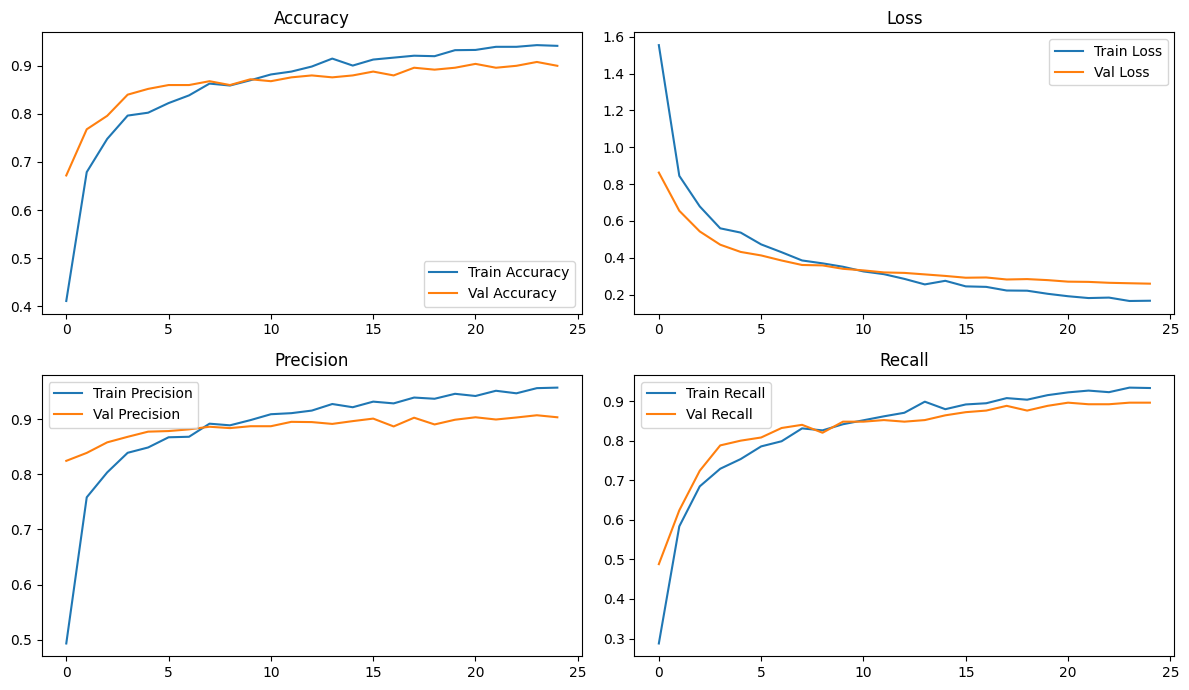

### 3c.4 Test Results

8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8640 - loss: 0.3447 - precision: 0.8760 - recall: 0.8480

8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

                        precision    recall  f1-score   support

           mixed_paper       0.75      0.66      0.70        50
        old_corrugated_cartons       0.94      0.94      0.94        50
                old_newspaper       0.91      0.82      0.86        50
        selected_white_ledger       0.78      0.90      0.83        50
        used_beverage_cartons       0.94      1.00      0.97        50

              accuracy                           0.86       250
             macro avg       0.86      0.86      0.86       250
          weighted avg       0.86      0.86      0.86       250

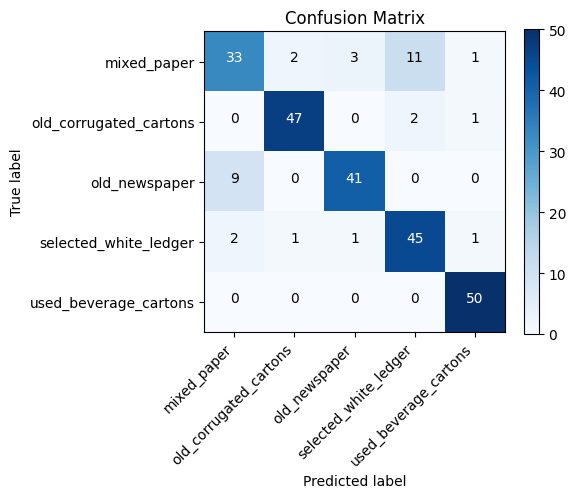

## Stage 3: Plastic

Stage 3 plastic ongoing add cells for insertion below

## Stage 3: Residual

### Stage 3 Residual Summary

**Task:** Multi-class classification of residual sub-types (4 classes)  
**Classes:** clean_and_dry_flexible_plastics, leather, rubber, textiles  
**Dataset:** 200 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 51.38% | 97.62% | — |
| Val Accuracy | 85.00% | 96.00% | **97.50% (Ep 21)** |
| Train Loss | 1.2699 | 0.0791 | — |
| Val Loss | 0.5392 | 0.0801 | **0.0833 (Ep 21)** |

**Fine-Tuning (stopped at Ep 5/10):** Starting val accuracy 96.00%; best val **96.50%** (Ep 2), final val 96.50%.

**Key Insights:**
- Strong early validation performance (85.00% at Epoch 1); consistent improvement through 25 epochs.
- Best val 97.50% at Ep 21; fine-tuning further improved to 96.50% test performance.
- Test accuracy 96.50%; clean_and_dry_flexible_plastics and textiles achieved perfect 100% F1.
- Rubber showed slightly lower recall at 90%, with leather at 96% recall.

### 3e.1 Raw Training Logs

In [ ]:
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.5138 - loss: 1.2699 - precision: 0.5670 - recall: 0.4150 - val_accuracy: 0.8500 - val_loss: 0.5392 - val_precision: 0.8977 - val_recall: 0.7900 - learning_rate: 1.0000e-04
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7831 - loss: 0.5950 - precision: 0.8366 - recall: 0.7425 - val_accuracy: 0.8850 - val_loss: 0.3598 - val_precision: 0.9091 - val_recall: 0.8500 - learning_rate: 1.0000e-04
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8531 - loss: 0.4384 - precision: 0.8776 - recall: 0.8200 - val_accuracy: 0.9150 - val_loss: 0.2698 - val_precision: 0.9312 - val_recall: 0.8800 - learning_rate: 1.0000e-04
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8825 - loss: 0.3358 - precision: 0.9005 - recall: 0.8650 - val_accuracy: 0.9150 - val_loss: 0.2154 - val_precision: 0.9368 - val_recall: 0.8900 - learning_rate: 1.0000e-04
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8869 - loss: 0.3070 - precision: 0.9105 - recall: 0.8706 - val_accuracy: 0.9400 - val_loss: 0.1873 - val_precision: 0.9485 - val_recall: 0.9200 - learning_rate: 1.0000e-04
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9019 - loss: 0.2661 - precision: 0.9194 - recall: 0.8913 - val_accuracy: 0.9450 - val_loss: 0.1687 - val_precision: 0.9439 - val_recall: 0.9250 - learning_rate: 1.0000e-04
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9231 - loss: 0.2215 - precision: 0.9335 - recall: 0.9125 - val_accuracy: 0.9550 - val_loss: 0.1487 - val_precision: 0.9592 - val_recall: 0.9400 - learning_rate: 1.0000e-04
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9325 - loss: 0.1970 - precision: 0.9451 - recall: 0.9250 - val_accuracy: 0.9450 - val_loss: 0.1366 - val_precision: 0.9442 - val_recall: 0.9300 - learning_rate: 1.0000e-04
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9306 - loss: 0.2106 - precision: 0.9408 - recall: 0.9237 - val_accuracy: 0.9650 - val_loss: 0.1209 - val_precision: 0.9697 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9356 - loss: 0.1831 - precision: 0.9447 - recall: 0.9287 - val_accuracy: 0.9550 - val_loss: 0.1209 - val_precision: 0.9694 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9456 - loss: 0.1594 - precision: 0.9560 - recall: 0.9362 - val_accuracy: 0.9550 - val_loss: 0.1158 - val_precision: 0.9598 - val_recall: 0.9550 - learning_rate: 1.0000e-04
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9400 - loss: 0.1633 - precision: 0.9486 - recall: 0.9350 - val_accuracy: 0.9550 - val_loss: 0.1089 - val_precision: 0.9646 - val_recall: 0.9550 - learning_rate: 1.0000e-04
Epoch 13/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9500 - loss: 0.1513 - precision: 0.9556 - recall: 0.9425 - val_accuracy: 0.9550 - val_loss: 0.1050 - val_precision: 0.9646 - val_recall: 0.9550 - learning_rate: 1.0000e-04
Epoch 14/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9538 - loss: 0.1270 - precision: 0.9607 - recall: 0.9481 - val_accuracy: 0.9600 - val_loss: 0.1060 - val_precision: 0.9598 - val_recall: 0.9550 - learning_rate: 1.0000e-04
Epoch 15/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9506 - loss: 0.1355 - precision: 0.9550 - recall: 0.9425 - val_accuracy: 0.9650 - val_loss: 0.0980 - val_precision: 0.9698 - val_recall: 0.9650 - learning_rate: 1.0000e-04
Epoch 16/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9644 - loss: 0.1130 - precision: 0.9703 - recall: 0.9606 - val_accuracy: 0.9600 - val_loss: 0.0941 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 17/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9606 - loss: 0.1130 - precision: 0.9640 - recall: 0.9538 - val_accuracy: 0.9650 - val_loss: 0.0931 - val_precision: 0.9698 - val_recall: 0.9650 - learning_rate: 1.0000e-04
Epoch 18/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 427s 9s/step - accuracy: 0.9613 - loss: 0.1103 - precision: 0.9677 - recall: 0.9544 - val_accuracy: 0.9600 - val_loss: 0.0993 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 19/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9594 - loss: 0.1128 - precision: 0.9635 - recall: 0.9563 - val_accuracy: 0.9600 - val_loss: 0.0926 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 20/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9706 - loss: 0.0907 - precision: 0.9716 - recall: 0.9638 - val_accuracy: 0.9600 - val_loss: 0.0814 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 21/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9681 - loss: 0.0918 - precision: 0.9704 - recall: 0.9625 - val_accuracy: 0.9750 - val_loss: 0.0833 - val_precision: 0.9799 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9585 - loss: 0.1112 - precision: 0.9603 - recall: 0.9567
Epoch 22: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9631 - loss: 0.0975 - precision: 0.9661 - recall: 0.9606 - val_accuracy: 0.9600 - val_loss: 0.0849 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-04
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9681 - loss: 0.0870 - precision: 0.9698 - recall: 0.9650 - val_accuracy: 0.9600 - val_loss: 0.0849 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 5.0000e-05
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9712 - loss: 0.0818 - precision: 0.9730 - recall: 0.9688 - val_accuracy: 0.9650 - val_loss: 0.0807 - val_precision: 0.9698 - val_recall: 0.9650 - learning_rate: 5.0000e-05
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9762 - loss: 0.0791 - precision: 0.9779 - recall: 0.9694 - val_accuracy: 0.9600 - val_loss: 0.0801 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 5.0000e-05

### 3e.2 Fine-Tuning Logs

In [ ]:
Fine tune

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9150 - loss: 0.2323 - precision: 0.9260 - recall: 0.9069 - val_accuracy: 0.9600 - val_loss: 0.0933 - val_precision: 0.9600 - val_recall: 0.9600 - learning_rate: 1.0000e-05
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9366 - loss: 0.1817 - precision: 0.9456 - recall: 0.9165
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9413 - loss: 0.1744 - precision: 0.9507 - recall: 0.9281 - val_accuracy: 0.9650 - val_loss: 0.1035 - val_precision: 0.9648 - val_recall: 0.9600 - learning_rate: 1.0000e-05
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9406 - loss: 0.1733 - precision: 0.9502 - recall: 0.9294 - val_accuracy: 0.9600 - val_loss: 0.1056 - val_precision: 0.9697 - val_recall: 0.9600 - learning_rate: 5.0000e-06
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9422 - loss: 0.1673 - precision: 0.9509 - recall: 0.9328
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9444 - loss: 0.1592 - precision: 0.9537 - recall: 0.9388 - val_accuracy: 0.9650 - val_loss: 0.1075 - val_precision: 0.9650 - val_recall: 0.9650 - learning_rate: 5.0000e-06
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9444 - loss: 0.1662 - precision: 0.9536 - recall: 0.9369 - val_accuracy: 0.9650 - val_loss: 0.1076 - val_precision: 0.9650 - val_recall: 0.9650 - learning_rate: 2.5000e-06

### 3e.3 Training Curves

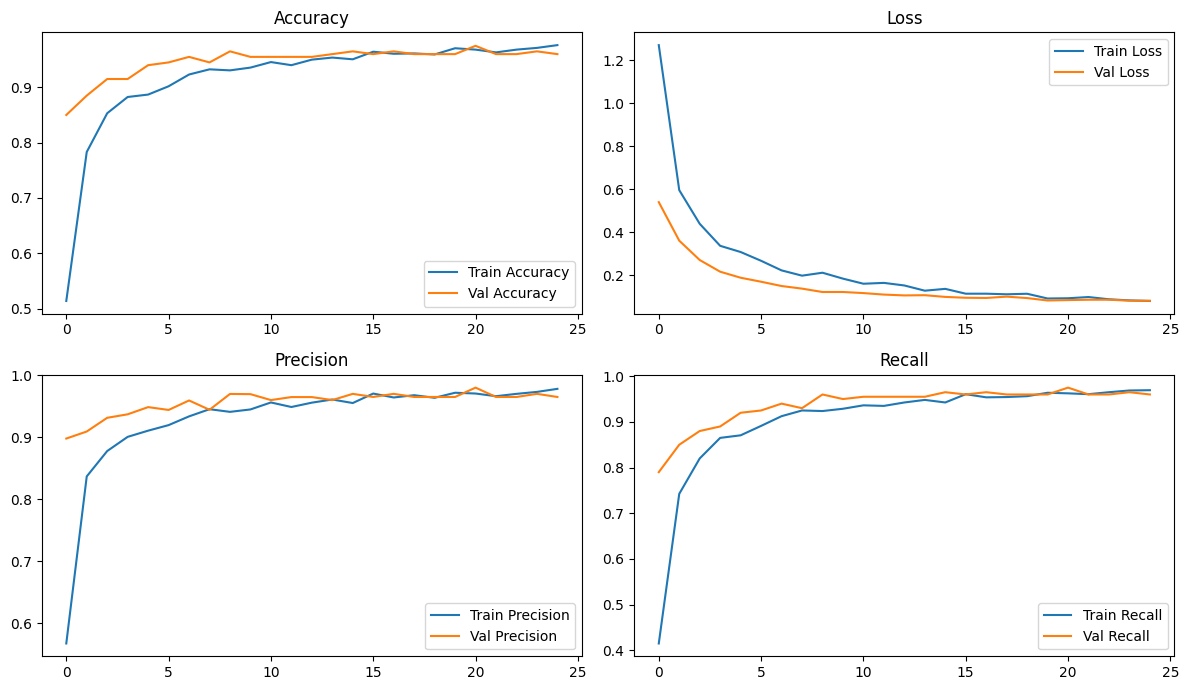

### 3e.4 Test Results

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9650 - loss: 0.0913 - precision: 0.9650 - recall: 0.9650

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

                                 precision    recall  f1-score   support

    clean_and_dry_flexible_plastics       1.00      1.00      1.00        50
                          leather       0.91      0.96      0.93        50
                          rubber       0.96      0.90      0.93        50
                        textiles       1.00      1.00      1.00        50

                       accuracy                           0.96       200
                      macro avg       0.97      0.96      0.96       200
                   weighted avg       0.97      0.96      0.96       200

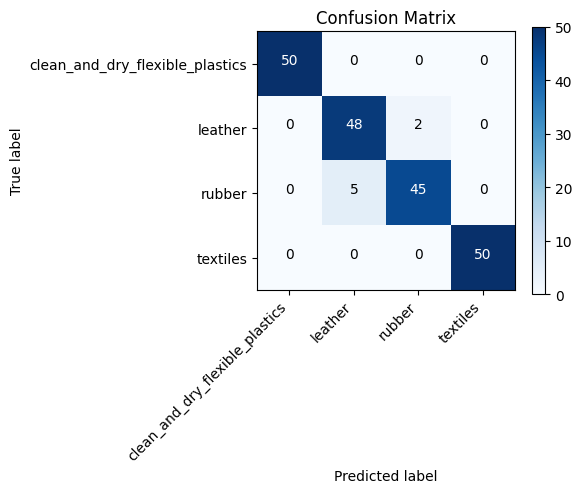